In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05

In [3]:
pTrue = 0.50499
thetaTrue = np.arcsin(np.sqrt(pTrue))

In [4]:
# 次のroundに行く場合はNaNとする
nEstim = 10000
minRatio = 2
#nGrovers = np.arange(100, 400, 5)
nGrovers = [150, 200, 300, 350]
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2, endCriterion="Angle")
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

150 0.024390243902439025 2023-11-06 10:42:16.796838
150 0.04878048780487805 2023-11-06 10:42:48.100958
150 0.07317073170731708 2023-11-06 10:43:25.014664
150 0.0975609756097561 2023-11-06 10:44:12.934129
150 0.12195121951219512 2023-11-06 10:45:22.856939
150 0.14634146341463417 2023-11-06 10:46:46.149392
150 0.17073170731707318 2023-11-06 10:47:55.117439
150 0.1951219512195122 2023-11-06 10:48:37.435837
150 0.21951219512195122 2023-11-06 10:49:03.401639
150 0.24390243902439024 2023-11-06 10:49:20.966602
150 0.2682926829268293 2023-11-06 10:49:35.626720
150 0.29268292682926833 2023-11-06 10:49:53.217516
150 0.3170731707317073 2023-11-06 10:50:15.273075
150 0.34146341463414637 2023-11-06 10:50:43.059652
150 0.36585365853658536 2023-11-06 10:51:29.828495
150 0.3902439024390244 2023-11-06 10:52:41.105798
150 0.41463414634146345 2023-11-06 10:53:51.311110
150 0.43902439024390244 2023-11-06 10:54:39.653038
150 0.4634146341463415 2023-11-06 10:55:19.923751
150 0.4878048780487805 2023-11-06 10

<ipython-input-4-95f169f6886b>:27: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


150 0.951219512195122 2023-11-06 11:05:12.198032
150 0.975609756097561 2023-11-06 11:05:23.627383
200 0.024390243902439025 2023-11-06 11:05:35.907730
200 0.04878048780487805 2023-11-06 11:05:38.176609
200 0.07317073170731708 2023-11-06 11:05:40.595873
200 0.0975609756097561 2023-11-06 11:05:43.164902
200 0.12195121951219512 2023-11-06 11:05:46.323626
200 0.14634146341463417 2023-11-06 11:05:49.923600
200 0.17073170731707318 2023-11-06 11:05:54.474424
200 0.1951219512195122 2023-11-06 11:05:59.624205
200 0.21951219512195122 2023-11-06 11:06:04.853823
200 0.24390243902439024 2023-11-06 11:06:09.722132
200 0.2682926829268293 2023-11-06 11:06:14.640258
200 0.29268292682926833 2023-11-06 11:06:19.441567
200 0.3170731707317073 2023-11-06 11:06:24.400256
200 0.34146341463414637 2023-11-06 11:06:29.557661
200 0.36585365853658536 2023-11-06 11:06:34.585221
200 0.3902439024390244 2023-11-06 11:06:38.644510
200 0.41463414634146345 2023-11-06 11:06:41.842588
200 0.43902439024390244 2023-11-06 11:0

In [ ]:
resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_EndTheta_p0.50499.csv", index=False)

In [7]:
resDf[resDf["nGrover"]==150]

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,150.0,75.0,0.024390,-1.648762e-04,10000.0,10000.0
1,150.0,75.0,0.048780,-2.022857e-04,10000.0,10000.0
2,150.0,75.0,0.073171,-1.747240e-04,10000.0,10000.0
3,150.0,75.0,0.097561,-1.397515e-04,10000.0,10000.0
4,150.0,75.0,0.121951,-8.227127e-05,10000.0,9999.0
5,150.0,75.0,0.146341,1.004399e-06,10000.0,9967.0
6,150.0,75.0,0.170732,2.378099e-05,10000.0,9603.0
7,150.0,75.0,0.195122,-3.865177e-05,10000.0,8242.0
8,150.0,75.0,0.219512,-1.415721e-04,10000.0,5442.0
9,150.0,75.0,0.243902,-6.990146e-05,10000.0,3368.0


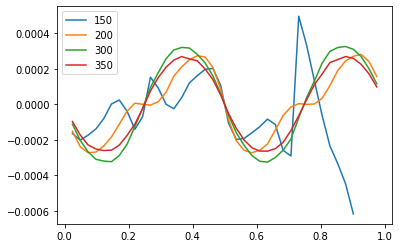

In [9]:
ax = plt.gca()
for nG in [150,200,300,350]:
    resDfPart = resDf[resDf["nGrover"] == nG]
    plt.plot(resDfPart["AngleFrac"], resDfPart["Bias"], label=str(nG))
plt.legend()
plt.show()

In [ ]:
nGroversExp = np.array([r["nGrover"][-1] for r in resDf])
angleFracExp = np.modf((2 * nGroversExp + 1) * thetaTrue / np.pi)[0]

In [ ]:
np.unique(nGroversExp, return_counts=True)

(array([116, 119, 122, 123, 125, 126, 128, 129, 131, 132, 134, 135, 137,
        138, 140, 141, 143, 144, 146, 147, 149, 150, 152, 153, 155, 156,
        158, 159, 161, 162, 164, 165, 167, 168, 170, 171, 173, 174, 176,
        177, 179, 180, 182, 183, 185, 186, 187, 188, 189, 191, 192, 193,
        194, 195, 196, 197, 198, 199, 200, 201, 203, 204, 205, 206, 207,
        209, 210, 212, 213, 214, 216, 217, 218, 219, 220, 221, 222, 223,
        224, 225, 226, 227, 228, 230, 231, 232, 233, 234, 235, 236, 237,
        238, 239, 240, 241, 242, 243, 244, 245, 246, 248, 249, 250, 251,
        252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264,
        265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277,
        278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290,
        291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
        304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316,
        317, 318, 319, 320, 321, 322, 323, 324, 325

In [ ]:
# End num 少なすぎるところはNaNに
resDf_RemoveSmallNum = resDf.copy()
resDf_RemoveSmallNum["Bias"] = np.where(resDf_RemoveSmallNum["NumEnd"] < 1000, np.nan, resDf_RemoveSmallNum["Bias"])
biasMat = np.reshape(np.array(resDf_RemoveSmallNum["Bias"]), (len(nGrovers), len(angleFracs))).T

In [ ]:
# matrixを補間
nGsInterp = np.arange(100, 401)

angMargin = angleFracs[0] / 4
angStep = angleFracs[0] / 2
argInterp = np.arange(angMargin, 1, angStep)
iAngVec = [np.abs(angleFracs - a).argmin() for a in argInterp]

biasMatInterp = np.zeros((len(argInterp), len(nGsInterp)))

for ingInterp in range(len(nGsInterp)):
    nGInterp = nGsInterp[ingInterp]
    ingOrg = np.abs(nGrovers - nGInterp).argmin()
    biasMatInterp[:,ingInterp] = biasMat[iAngVec,ingOrg]

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

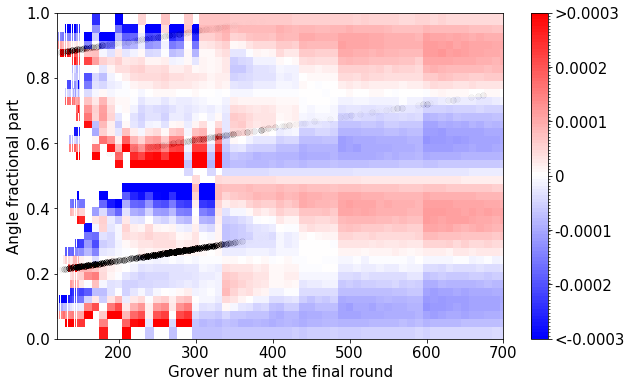

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
levels = MaxNLocator(nbins=100).tick_values(-0.0003, 0.0003)
cmap = plt.colormaps['bwr']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
heatmap = ax.pcolor(nGsInterp, argInterp, biasMatInterp, cmap="bwr", norm=norm)
cbar = fig.colorbar(heatmap, ax=ax) # カラーバー

ticks  = np.arange(-0.0003, 0.00031, 0.0001)
labels = ['<-0.0003', '-0.0002', '-0.0001', '0', '0.0001', '0.0002', '>0.0003']
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)
cbar.ax.tick_params(axis='y', labelsize=15)

ax.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)
ax.set_ylim(0,1)
ax.set_xlim(100,400)
ax.set_xlabel("Grover num at the final round", fontsize=15)
ax.set_ylabel("Angle fractional part", fontsize=15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.savefig("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/BiasHeatmap&NGrovFracAngleScatter_EndTheta_p0.50499.png")
plt.show()